# Data Science Capstone, Adult Census Income: Baseline Model

- The baseline modeling milestone: I train the simplest reasonable model as an honest benchmark every later model has to beat.
- The model is logistic regression, my interpretable baseline and the null case for H3.
- Task: predict whether a person earns over \$50K from their demographic, education, and job info, framed as a lender that flags likely high earners.
- So I care about which features drive the decision and how many real high earners I catch, not raw accuracy.

## Project recap: dataset and hypotheses

Dataset
- UCI Adult Census Income data, from the 1994 U.S. Census: about 32,500 rows, one person per row.
- Target: whether a person earns over \$50K a year; the classes are imbalanced (about 24 percent high earners).

The three hypotheses the project tests
- H1: education level drives the over-\$50K prediction more than hours worked.
- H2: of the three models, XGBoost is the fairest across nativity, with the smallest US-born vs foreign-born recall gap on true high earners, smaller than logistic regression and the MLP.
- H3: XGBoost beats both the logistic baseline and the MLP on held-out PR-AUC and F1.
- This milestone builds the logistic regression baseline that H3 is measured against.

## Setup

In [1]:
# libraries, the navy and gold plot colors I use across the project, and a fixed seed
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import sqlite3, time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

NAVY = "#1f3a5f"
GOLD = "#c9a227"
SEED = 42
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

In [2]:
# the small performance helper from class, so the before and after models print the same way
def measure_performance(X, y, clf, show_accuracy=True, show_classification_report=True, show_confusion_matrix=True):
    y_pred = clf.predict(X)
    if show_accuracy:
        print("Accuracy:{0:.3f}".format(metrics.accuracy_score(y, y_pred)), "\n")
    if show_classification_report:
        print("Classification report")
        print(metrics.classification_report(y, y_pred), "\n")
    if show_confusion_matrix:
        print("Confusion matrix")
        print(metrics.confusion_matrix(y, y_pred), "\n")

## Loading and preparing the data

- Pull the data back out of the SQLite database and rebuild the cleaned, feature-engineered table from my EDA milestone.
- Same preprocessing I justified there: Unknown bucket for missing categoricals, drop the 24 duplicates before dropping fnlwgt, drop fnlwgt and the redundant education column, clean the target, add the fairness and capital flags.
- I just run it here rather than re-arguing it.

In [3]:
# read the raw csv into the database, then pull it back out into the dataframe I model on
raw = pd.read_csv("adult.csv", na_values="?", skipinitialspace=True)
conn = sqlite3.connect("adult.db")
raw.to_sql("adult", conn, if_exists="replace", index=False)
df = pd.read_sql("SELECT * FROM adult", conn)
conn.close()
print("Pulled", df.shape[0], "rows from the database")

Pulled 32561 rows from the database


In [4]:
# fill missing categoricals with Unknown, drop duplicates before dropping fnlwgt, then drop fnlwgt and education
for col in ["workclass", "occupation", "native.country"]:
    df[col] = df[col].fillna("Unknown")
df = df.drop_duplicates()
df = df.drop(columns=["fnlwgt", "education"])
print("Shape after cleaning:", df.shape)

Shape after cleaning: (32537, 13)


In [5]:
# clean the target label, switch the dotted column names to underscores, and add the 1/0 target
df["income"] = df["income"].str.strip().str.replace(".", "", regex=False)
df.columns = df.columns.str.replace(".", "_", regex=False)
df["high_income"] = (df["income"] == ">50K").astype(int)
print(df["income"].unique(), "-> positive rate", round(df["high_income"].mean(), 3))

<StringArray>
['<=50K', '>50K']
Length: 2, dtype: str -> positive rate 0.241


In [6]:
# rebuild the engineered features from the EDA milestone
df["native_region"] = df["native_country"].apply(
    lambda c: "US" if c == "United-States" else ("Unknown" if c == "Unknown" else "non-US"))
df["has_capital_gain"] = (df["capital_gain"] > 0).astype(int)
df["has_capital_loss"] = (df["capital_loss"] > 0).astype(int)
df["hours_group"] = pd.cut(df["hours_per_week"], bins=[0, 20, 35, 40, 45, 60, 100],
                           labels=["<=20", "21-35", "36-40", "41-45", "46-60", "60+"])
print("Feature engineered columns added")

Feature engineered columns added


In [7]:
# one hot encode the categoricals and join the numeric columns into the model matrix X, with y as the target
cat_cols = ["workclass", "marital_status", "occupation", "relationship",
            "race", "sex", "native_region", "hours_group"]
num_cols = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week",
            "has_capital_gain", "has_capital_loss"]
X = pd.get_dummies(df[cat_cols], drop_first=True).astype(int)
X = pd.concat([df[num_cols], X], axis=1)
y = df["high_income"]
print("Model matrix X:", X.shape, " target y:", y.shape)

Model matrix X: (32537, 52)  target y: (32537,)


## The model I chose and why

- Data fit: about 52 mostly-binary columns plus a few numeric ones, dense and tabular, with no images, text, or time-series, so nothing calls for a fancier model.
- Task fit: the target is binary, and logistic regression is a classifier built for exactly that.
- Interpretability: my lender use case has to explain what the model keyed on, and it trains in seconds, so it is a strong baseline choice.
- How it works: a weighted sum of the features through the sigmoid gives a probability, with one signed coefficient per feature, then a 0.5 threshold for yes or no.
- The limit: it is linear and additive, so it misses interactions and curves unless I hand-engineer them, which is why later milestones try more flexible models.

## The split, and how I handle the class imbalance

- Split: a stratified 20 percent test set I do not touch until the end; all tuning happens on the training 80 percent, so cross-validation is my validation set.
- Imbalance: about 24 percent earn over \$50K, so I oversample the minority with SMOTE rather than throw away real rows by undersampling.
- The rule that matters: resample after the split and only on training rows, so scaler, SMOTE, and model go in one pipeline and SMOTE never sees held-out rows.

In [8]:
# hold out a stratified 20 percent test set, keep the rest for training and cross-validation
from sklearn.model_selection import train_test_split
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print("Train:", Xtr.shape[0], " Test:", Xte.shape[0])
print("Positive rate  train:", round(ytr.mean(), 3), " test:", round(yte.mean(), 3))

Train: 26029  Test: 6508
Positive rate  train: 0.241  test: 0.241


In [9]:
# scale only the continuous numeric columns, leaving the 0/1 dummies and flags as they are
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
scale_cols = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
pre = ColumnTransformer([("scale", StandardScaler(), scale_cols)], remainder="passthrough")
print("Scaling", len(scale_cols), "numeric columns, passing the rest through unchanged")

Scaling 5 numeric columns, passing the rest through unchanged


In [10]:
# one pipeline so scaling and SMOTE are fit on training folds only, never on the held-out rows
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
baseline_pipe = ImbPipeline([
    ("prep", pre),
    ("smote", SMOTE(random_state=SEED)),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
])
baseline_pipe

,steps,"[('prep', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string

## The metrics I use to evaluate

- I define the metrics once here, since every result below reports them. Writing TP, TN, FP, FN for true and false positives and negatives:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}, \qquad \text{Precision} = \frac{TP}{TP + FP}, \qquad \text{Recall} = \frac{TP}{TP + FN}$$

$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

- Accuracy: overall share correct, which is misleading here since always guessing the majority class already scores about 76 percent.
- Precision: of the people I flag as high earners, how many really are.
- Recall: of the real high earners, how many I catch.
- F1: the harmonic mean of precision and recall, low unless both are decent.
- PR-AUC (my lead metric): area under the precision-recall curve, focused on the positive class, with a no-skill floor at the 0.241 positive rate.
- ROC-AUC: area under the true-positive vs false-positive-rate curve; it ranks across all thresholds but flatters on imbalanced data.

## A naive baseline to beat

- First I fit the most naive predictor: always guess the majority class.
- This is the floor I have to beat to show the model is learning anything, and it makes the accuracy trap concrete.

In [11]:
# majority-class predictor, the floor every real model has to clear
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED).fit(Xtr, ytr)
dummy_pred = dummy.predict(Xte)
print("Accuracy:", round(metrics.accuracy_score(yte, dummy_pred), 3))
print("Recall on real >50K earners:", round(metrics.recall_score(yte, dummy_pred), 3))
print("PR-AUC (equals the positive base rate here):", round(metrics.average_precision_score(yte, dummy.predict_proba(Xte)[:, 1]), 3))

Accuracy: 0.759
Recall on real >50K earners: 0.0
PR-AUC (equals the positive base rate here): 0.241


- Always guessing the majority class scores about 76 percent accuracy while catching zero real high earners.
- Its PR-AUC just sits at the 0.241 base rate, so there is no signal at all.
- So accuracy is misleading: a useless model already scores in the high 70s, and recall of 0 gives it away.
- This is the floor every real model has to clear.

## The untuned baseline model compared to model with SMOTE

- The actual model with default settings, my before-state to measure later changes against.
- I run it two ways on the same test rows: on the raw imbalance, then with SMOTE added, to show what handling the imbalance does.

In [12]:
# default logistic regression on the raw imbalance, scaled but with no resampling
from sklearn.pipeline import Pipeline as SkPipeline
before = SkPipeline([("prep", pre), ("clf", LogisticRegression(max_iter=1000, random_state=SEED))]).fit(Xtr, ytr)
print("Default logistic regression, trained on the raw imbalanced data")
measure_performance(Xte, yte, before, show_confusion_matrix=False)

Default logistic regression, trained on the raw imbalanced data
Accuracy:0.851 

Classification report
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      4940
           1       0.74      0.59      0.66      1568

    accuracy                           0.85      6508
   macro avg       0.81      0.76      0.78      6508
weighted avg       0.84      0.85      0.85      6508
 



In [13]:
# same default model but with SMOTE oversampling on the training folds only
baseline_pipe.fit(Xtr, ytr)
print("Default logistic regression, with SMOTE on the training data")
measure_performance(Xte, yte, baseline_pipe, show_confusion_matrix=False)

Default logistic regression, with SMOTE on the training data
Accuracy:0.816 

Classification report
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      4940
           1       0.58      0.81      0.68      1568

    accuracy                           0.82      6508
   macro avg       0.76      0.82      0.78      6508
weighted avg       0.85      0.82      0.82      6508
 



In [14]:
# put the two before states side by side on the metrics I actually care about
def score_row(name, model, X_, y_):
    p = model.predict(X_)
    prob = model.predict_proba(X_)[:, 1]
    return {"model": name,
            "accuracy": metrics.accuracy_score(y_, p),
            "precision": metrics.precision_score(y_, p),
            "recall": metrics.recall_score(y_, p),
            "f1": metrics.f1_score(y_, p),
            "PR-AUC": metrics.average_precision_score(y_, prob),
            "ROC-AUC": metrics.roc_auc_score(y_, prob)}

before_after = pd.DataFrame([
    score_row("Raw imbalance", before, Xte, yte),
    score_row("With SMOTE", baseline_pipe, Xte, yte),
]).set_index("model").round(3)
print(before_after.to_string())

               accuracy  precision  recall     f1  PR-AUC  ROC-AUC
model                                                             
Raw imbalance     0.851      0.739   0.591  0.657   0.775    0.905
With SMOTE        0.816      0.584   0.814  0.681   0.774    0.905


- On the raw imbalance the model catches only about 59 percent of real high earners.
- Adding SMOTE lifts recall into the low 80s, so I catch far more of them.
- The cost is some precision (more false alarms); F1 ticks up only slightly.
- PR-AUC and ROC-AUC barely move, because SMOTE shifts where the 0.5 cutoff lands, not how well the model ranks people.
- For a lender that would rather flag a borderline case than miss a real high earner, that is the right trade, so I carry SMOTE forward.

## Cross-validating the baseline model

- A single train/test number can be lucky, so I cross-validate the SMOTE pipeline on the training data.
- 5-fold stratified: k=5 keeps enough minority-class rows per fold for a steady PR-AUC, and stratifying holds the 24 percent positive rate in every fold.
- Passing the whole pipeline in refits SMOTE inside each fold, so there is no leakage.
- I report the mean and the spread across folds.

In [15]:
# 5-fold stratified cross-validation on the training data, scored on the imbalance-aware metrics
from sklearn.model_selection import cross_validate, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_res = cross_validate(baseline_pipe, Xtr, ytr, cv=cv,
                        scoring=["average_precision", "f1", "recall"])
for m, label in [("average_precision", "PR-AUC"), ("f1", "F1"), ("recall", "Recall")]:
    s = cv_res["test_" + m]
    print(f"{label:8s} mean {s.mean():.3f}   std {s.std():.3f}   (variance {s.var():.5f})")

PR-AUC   mean 0.777   std 0.008   (variance 0.00006)
F1       mean 0.689   std 0.006   (variance 0.00004)
Recall   mean 0.842   std 0.013   (variance 0.00016)


- Cross-validated PR-AUC sits around 0.78, with a standard deviation under 0.01.
- F1 and recall are just as tight across folds.
- A spread that small means the baseline is stable, not riding on one lucky split, so the test numbers hold up as a benchmark.

## Tuning hyperparameters with Grid Search

- Logistic regression has few knobs, so I tune the two that shape it, with the same 5-fold CV scored on PR-AUC.
- C (inverse regularization strength): small C means stronger regularization and a simpler model that risks underfitting; large C means weaker regularization that fits the training data more closely and risks overfitting.
- penalty: L2 shrinks all coefficients smoothly, while L1 can zero some out and act like a light feature selector, so it is worth trying against L2.
- I search with the liblinear solver and compare tuned vs untuned on the same test rows.

In [16]:
# grid search over C and the L1/L2 penalty, cross-validated on PR-AUC
from sklearn.model_selection import GridSearchCV
tune_pipe = ImbPipeline([
    ("prep", pre),
    ("smote", SMOTE(random_state=SEED)),
    ("clf", LogisticRegression(max_iter=2000, solver="liblinear", random_state=SEED)),
])
param_grid = {"clf__C": [0.01, 0.1, 1, 10], "clf__penalty": ["l1", "l2"]}
grid = GridSearchCV(tune_pipe, param_grid, scoring="average_precision", cv=cv, n_jobs=-1)
grid.fit(Xtr, ytr)
print("Best parameters:", grid.best_params_)
print("Best cross-validated PR-AUC:", round(grid.best_score_, 3))

Best parameters: {'clf__C': 10, 'clf__penalty': 'l1'}
Best cross-validated PR-AUC: 0.778


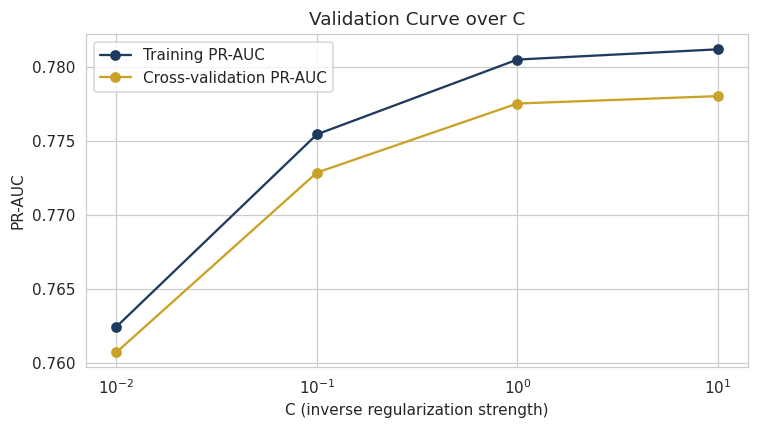

In [17]:
# validation curve over C to see the underfitting-to-overfitting picture directly
from sklearn.model_selection import validation_curve
C_range = [0.01, 0.1, 1, 10]
train_sc, val_sc = validation_curve(tune_pipe, Xtr, ytr, param_name="clf__C",
                                    param_range=C_range, scoring="average_precision", cv=cv, n_jobs=-1)
plt.figure(figsize=(7, 4))
plt.plot(C_range, train_sc.mean(axis=1), "o-", color=NAVY, label="Training PR-AUC")
plt.plot(C_range, val_sc.mean(axis=1), "o-", color=GOLD, label="Cross-validation PR-AUC")
plt.xscale("log")
plt.xlabel("C (inverse regularization strength)")
plt.ylabel("PR-AUC")
plt.title("Validation Curve over C")
plt.legend()
plt.tight_layout()
plt.show()

- Both lines are the same model scored two ways: training rows vs held-out CV folds taken from the training set (the test set is untouched here).
- The gap between them stays tiny (both about 0.78) across every C, so the model is not overfitting: it separates the classes about as well on unseen people as on training people.

In [18]:
# tuned vs untuned on the same held-out test rows
tuned = grid.best_estimator_
tune_table = pd.DataFrame([
    score_row("Untuned (default C, L2)", baseline_pipe, Xte, yte),
    score_row("Tuned", tuned, Xte, yte),
]).set_index("model").round(3)
print(tune_table.to_string())

                         accuracy  precision  recall     f1  PR-AUC  ROC-AUC
model                                                                       
Untuned (default C, L2)     0.816      0.584   0.814  0.681   0.774    0.905
Tuned                       0.816      0.585   0.817  0.682   0.775    0.905


- Tuning C and the penalty moves PR-AUC and F1 by only a thousandth or two, and the curve is flat by about C=1.
- letdown: logistic regression is low-variance and already near its ceiling on this data.
- A real jump has to come from a more flexible model, which is what H3 tests, not from squeezing this one harder.

## Evaluating the final baseline

- I settle on the tuned pipeline and evaluate it on the held-out test set using the metrics defined earlier.
- PR-AUC stays the lead number, with recall and F1 alongside, and accuracy and ROC-AUC secondary.

In [19]:
# final baseline metrics on the held-out test set
final_pred = tuned.predict(Xte)
final_prob = tuned.predict_proba(Xte)[:, 1]
print("Final baseline (tuned logistic regression) on the held-out test set\n")
print(metrics.classification_report(yte, final_pred, target_names=["<=50K", ">50K"]))
print("PR-AUC :", round(metrics.average_precision_score(yte, final_prob), 3))
print("ROC-AUC:", round(metrics.roc_auc_score(yte, final_prob), 3))

Final baseline (tuned logistic regression) on the held-out test set

              precision    recall  f1-score   support

       <=50K       0.93      0.82      0.87      4940
        >50K       0.58      0.82      0.68      1568

    accuracy                           0.82      6508
   macro avg       0.76      0.82      0.78      6508
weighted avg       0.85      0.82      0.83      6508

PR-AUC : 0.775
ROC-AUC: 0.905


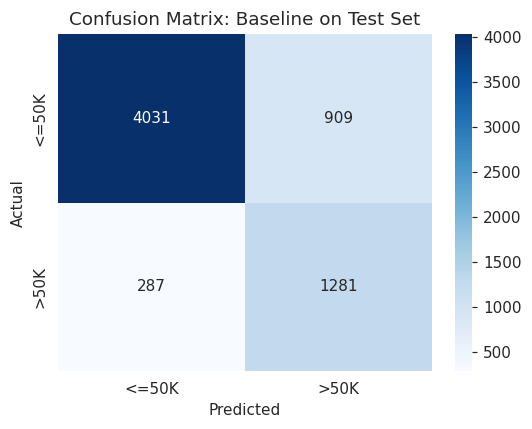

In [20]:
# confusion matrix so I can see exactly which way the errors go
cm = metrics.confusion_matrix(yte, final_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["<=50K", ">50K"], yticklabels=["<=50K", ">50K"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Baseline on Test Set")
plt.tight_layout()
plt.show()

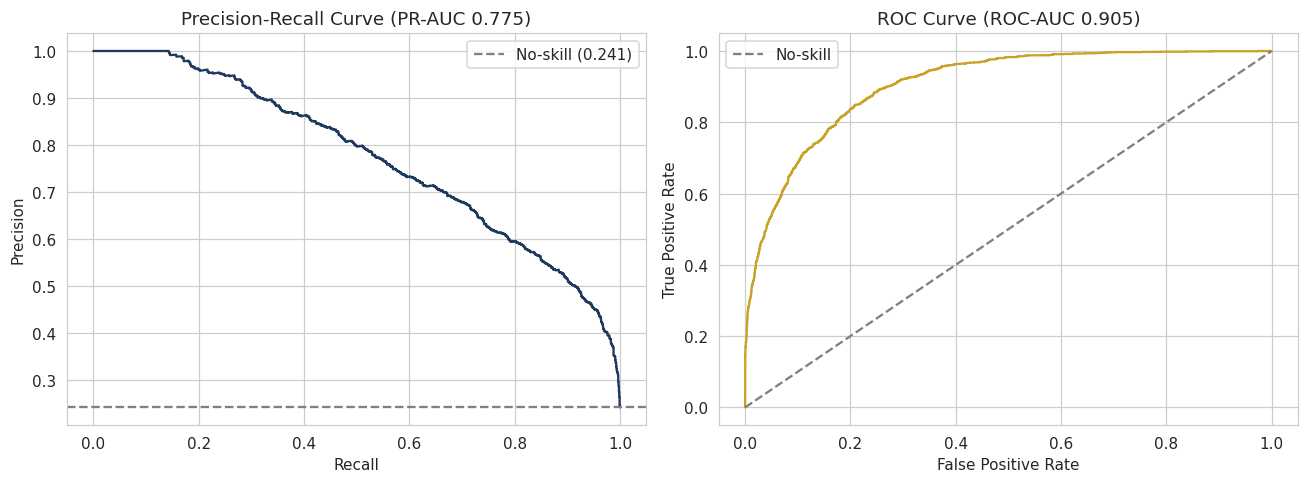

In [21]:
# precision-recall and ROC curves, with the no-skill reference lines
prec, rec, _ = metrics.precision_recall_curve(yte, final_prob)
fpr, tpr, _ = metrics.roc_curve(yte, final_prob)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(rec, prec, color=NAVY)
axes[0].axhline(yte.mean(), color="grey", ls="--", label=f"No-skill ({yte.mean():.3f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title(f"Precision-Recall Curve (PR-AUC {metrics.average_precision_score(yte, final_prob):.3f})")
axes[0].legend()
axes[1].plot(fpr, tpr, color=GOLD)
axes[1].plot([0, 1], [0, 1], color="grey", ls="--", label="No-skill")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title(f"ROC Curve (ROC-AUC {metrics.roc_auc_score(yte, final_prob):.3f})")
axes[1].legend()
plt.tight_layout()
plt.show()

- Precision-Recall: stays well above the 0.241 no-skill line the whole way, so the baseline has real signal on the minority class.
- ROC: bows far from the random diagonal, so it separates the two classes well overall.

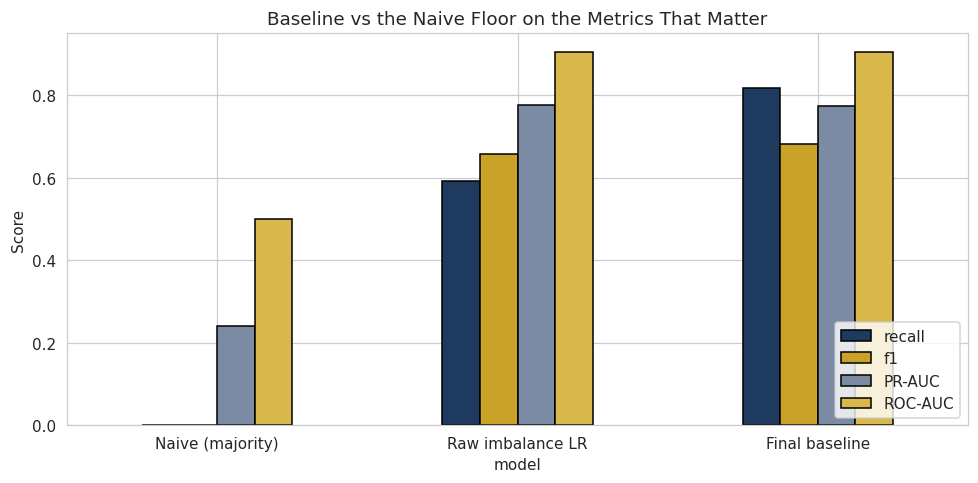

                  recall     f1  PR-AUC  ROC-AUC
model                                           
Naive (majority)   0.000  0.000   0.241    0.500
Raw imbalance LR   0.591  0.657   0.775    0.905
Final baseline     0.817  0.682   0.775    0.905


In [22]:
# one bar chart comparing the naive floor, the raw model, and the final baseline
compare = pd.DataFrame([
    score_row("Naive (majority)", dummy, Xte, yte),
    score_row("Raw imbalance LR", before, Xte, yte),
    score_row("Final baseline", tuned, Xte, yte),
]).set_index("model")[["recall", "f1", "PR-AUC", "ROC-AUC"]]
compare.plot(kind="bar", figsize=(9, 4.5), color=[NAVY, GOLD, "#7a8ba3", "#d8b84a"], edgecolor="black")
plt.title("Baseline vs the Naive Floor on the Metrics That Matter")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
print(compare.round(3).to_string())

- Confusion matrix: the baseline catches most real high earners with a moderate number of false alarms, which is the recall-first trade, on purpose.
- Bar chart: the naive model catches zero high earners, and my baseline clears it by a wide margin on recall, F1, and PR-AUC.
- This is the benchmark XGBoost and the MLP now have to beat.

## Learning curve: is more data the answer

- The validation curve already ruled out overfitting; the learning curve asks whether more rows would help.
- I plot PR-AUC against training set size for both the training folds and the cross-validation folds.

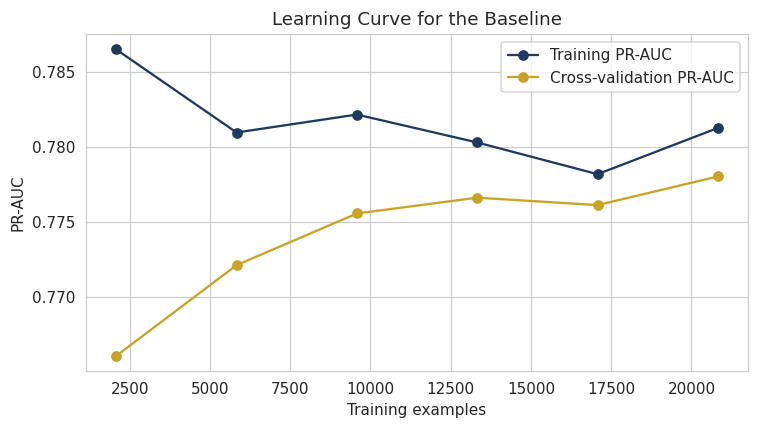

In [23]:
# learning curve: PR-AUC as the training set grows, training folds vs cross-validation folds
from sklearn.model_selection import learning_curve
sizes, lc_train, lc_val = learning_curve(
    tuned, Xtr, ytr, train_sizes=np.linspace(0.1, 1.0, 6),
    scoring="average_precision", cv=cv, n_jobs=-1, random_state=SEED)
plt.figure(figsize=(7, 4))
plt.plot(sizes, lc_train.mean(axis=1), "o-", color=NAVY, label="Training PR-AUC")
plt.plot(sizes, lc_val.mean(axis=1), "o-", color=GOLD, label="Cross-validation PR-AUC")
plt.xlabel("Training examples")
plt.ylabel("PR-AUC")
plt.title("Learning Curve for the Baseline")
plt.legend()
plt.tight_layout()
plt.show()

- The CV curve climbs fast on the first few thousand rows, then flattens, with the training curve only slightly above it.
- A small final gap plus a flat end means the model is not starved of data, so more rows would not buy much.
- The baseline is limited by the model and features, not the data, which again points to a more flexible model next.

## A quick error analysis

- Beyond the numbers, I want to see who the model gets wrong.
- I split the misclassified test rows by error type and compare their real feature values against the high earners the model caught, looking for a pattern.

In [24]:
# compare the original feature values of missed high earners, caught high earners, and false alarms
look = df.loc[Xte.index, ["education_num", "capital_gain", "hours_per_week", "age"]].copy()
look["true"] = yte.values
look["pred"] = final_pred
fn = look[(look["true"] == 1) & (look["pred"] == 0)]   # real high earners the model missed
tp = look[(look["true"] == 1) & (look["pred"] == 1)]   # real high earners the model caught
fp = look[(look["true"] == 0) & (look["pred"] == 1)]   # people wrongly flagged as high earners
err = pd.DataFrame({
    "missed >50K (FN)": fn.mean(numeric_only=True),
    "caught >50K (TP)": tp.mean(numeric_only=True),
    "false alarm (FP)": fp.mean(numeric_only=True),
}).round(1)
print("Counts:  missed", len(fn), " caught", len(tp), " false alarms", len(fp), "\n")
print(err.to_string())
print("\nShare with zero capital gain -> missed:", round((fn['capital_gain'] == 0).mean(), 3),
      " caught:", round((tp['capital_gain'] == 0).mean(), 3))

Counts:  missed 287  caught 1281  false alarms 909 

                missed >50K (FN)  caught >50K (TP)  false alarm (FP)
education_num               10.0              12.0              10.8
capital_gain               201.1            4547.3             271.7
hours_per_week              43.1              46.1              45.2
age                         41.0              45.3              44.1
true                         1.0               1.0               0.0
pred                         0.0               1.0               1.0

Share with zero capital gain -> missed: 0.944  caught: 0.76


- The high earners the model misses look ordinary on its strongest features: lower education, fewer hours, younger, and almost no capital gain.
- The ones it catches lean on those signals, capital gain especially: about 94 percent of the missed ones have zero capital gain.
- So capital gain does a lot of the work, and the model stumbles on high earners who got there without it.
- The false alarms are the mirror image: people who look like high earners on paper but are not.
- That fits a linear model reading each feature alone, and points to where a feature-combining model can help.

## Training and prediction time

- I want the baseline's cost on record before comparing against heavier models later.
- I time fitting the final pipeline and predicting on the test set.

In [25]:
# time how long the final baseline takes to fit and to predict
t0 = time.time(); tuned.fit(Xtr, ytr); fit_time = time.time() - t0
t0 = time.time(); _ = tuned.predict(Xte); pred_time = time.time() - t0
print(f"Fit time:     {fit_time:.2f} seconds")
print(f"Predict time: {pred_time:.4f} seconds on {len(Xte):,} rows")

Fit time:     3.64 seconds
Predict time: 0.0063 seconds on 6,508 rows


- The baseline trains in a few seconds and predicts almost instantly.
- That matters for the later comparison: if XGBoost or the MLP only edge it out on PR-AUC and F1 but cost far more and are harder to explain, the small gain has to be weighed against that.
- That trade-off is part of what H3 is really about.

## Where the baseline falls short, and what comes next

- Main flaw is built in: it's linear and additive, so it misses the curves and interactions my EDA already found (age, education × marital status).
- Leans hard on a few strong features — capital gain especially — and misses high earners who lack them.
- Vs XGBoost: it finds non-linear splits and interactions on its own, so I expect it to win on PR-AUC and F1 (H3).
- Trade-off: XGBoost gives up the transparency (and fast training) that keeps logistic regression as the baseline.
- Next steps: threshold tuning, train XGBoost + MLP with significance tests, then the nativity fairness audit (RQ2).

## Reproducibility note

- One fixed seed and a single load path from the database, so the notebook reruns to the same numbers.
- I print the library versions I ran on.

In [26]:
# fixed seed everywhere and the library versions, so this run can be reproduced
import sklearn, imblearn, scipy
print("random seed:", SEED)
for name, mod in [("numpy", np), ("pandas", pd), ("scikit-learn", sklearn),
                  ("imbalanced-learn", imblearn), ("scipy", scipy)]:
    print(f"{name:18s} {mod.__version__}")

random seed: 42
numpy              2.4.4
pandas             3.0.2
scikit-learn       1.8.0
imbalanced-learn   0.14.2
scipy              1.17.1


## How I used an LLM for this assignment

- I used an LLM to help debug my code and troubleshoot errors.
- It helped me format the output of my code so it showed the results the way I wanted it to
- It also helped me create some of the visual plots in this notebook.
- And I used it to help me correctly interpret the results of my data.